# f6_m01c_shap_cohortes.ipynb

## Qué hace
Analiza la importancia SHAP segmentada por cohortes: rama de conocimiento y titulación.
Responde a la pregunta: ¿qué variables son más importantes para predecir abandono
en cada grupo? ¿Es el modelo igual de explicable en todas las titulaciones?
Modelo usado: CatBoost__balanced.

## Requisitos
- `results/fase6/shap_global_catboost.pkl` (generado por f6_m01a)
- `data/05_modelado/X_test.parquet` (índices originales para el join)
- `data/05_modelado/X_test_prep.parquet`
- `data/05_modelado/y_test.parquet`
- `data/05_modelado/models/CatBoost__balanced.pkl`
- `data/03_features/df_exp_target_eda.parquet` (fuente de titulacion y per_id_ficticio)

## Genera
- `results/fase6/shap_cohortes_rama.parquet`
- `results/fase6/shap_cohortes_titulacion.parquet`
- `results/fase6/shap_cohortes_rama_top10.png`
- `results/fase6/shap_cohortes_titulacion_top8.png`
- `docs/html/fase6/m01c_shap_cohortes.html`

## Flujo
Cargar datos + modelo + SHAP global → calcular prob → join titulacion
→ segmentar por rama → segmentar por titulación → heatmaps → HTML

## Siguiente
`f6_m01d_shapash.ipynb` — dashboard interactivo de explicabilidad

In [1]:
# 1. CONFIGURACIÓN DE RUTAS
# ROOT detectado subiendo niveles hasta encontrar src/ — nunca hardcodeado
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

def _encontrar_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / 'src').is_dir():
            return parent
    raise FileNotFoundError('No se encontró src/ subiendo desde ' + str(start))

ROOT = _encontrar_root(Path.cwd())
sys.path.insert(0, str(ROOT))

DIR_DATA     = ROOT / 'data' / '05_modelado'
DIR_FEATURES = ROOT / 'data' / '03_features'
DIR_MODELS   = ROOT / 'data' / '05_modelado' / 'models'
DIR_RESULTS  = ROOT / 'results' / 'fase6'
DIR_RESULTS.mkdir(parents=True, exist_ok=True)

print(f'ROOT:        {ROOT}')
print(f'DIR_RESULTS: {DIR_RESULTS}')

ROOT:        C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI
DIR_RESULTS: C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI\results\fase6


In [2]:
# 2. IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import joblib
import shap
from src.html.render import render_pagina_desde_fichero

matplotlib.rcParams['figure.dpi'] = 120

print('Imports OK.')

Imports OK.


In [3]:
# 3. CARGAR DATOS, MODELO Y SHAP GLOBAL
# Disk-first: reutilizamos shap_cat de m01a.
# X_test (sin prep) para el join por índice. X_test_prep para SHAP y predict_proba.
# Los modelos de Fase 5 son sklearn.Pipeline con paso 'model'.
# NOTA: meta_test contiene metadatos del alumno, NO probabilidades predichas.

RUTA_SHAP_CAT = DIR_RESULTS / 'shap_global_catboost.pkl'
if not RUTA_SHAP_CAT.exists():
    raise FileNotFoundError(
        'No se encontró shap_global_catboost.pkl. '
        'Ejecuta primero f6_m01a_shap_global.ipynb.'
    )

X_test       = pd.read_parquet(DIR_DATA / 'X_test.parquet')
X_test_prep  = pd.read_parquet(DIR_DATA / 'X_test_prep.parquet')
y_test       = pd.read_parquet(DIR_DATA / 'y_test.parquet').squeeze()
shap_cat     = joblib.load(RUTA_SHAP_CAT)
pipeline_cat = joblib.load(DIR_MODELS / 'CatBoost__balanced.pkl')

feature_names = X_test_prep.columns.tolist()

print(f'X_test:      {X_test.shape}')
print(f'X_test_prep: {X_test_prep.shape}')
print(f'shap_cat:    {shap_cat.values.shape}')

X_test:      (6725, 19)
X_test_prep: (6725, 19)
shap_cat:    (6725, 19)


In [4]:
# 4. CALCULAR PROBABILIDADES Y JOIN TITULACIÓN
# Probabilidades con predict_proba sobre el Pipeline completo.
# Join titulacion: df_exp_target_eda tiene per_id_ficticio + titulacion + rama
# en el mismo orden que dataset_final_tfm.
# Los índices de X_test son posiciones iloc en df_ref — validado:
# max(X_test.index)=33619 < len(df_ref)=33621 → sin gaps.

prob  = pipeline_cat.predict_proba(X_test_prep)[:, 1]
y_arr = y_test.values.ravel()
print(f'Probabilidades: min={prob.min():.3f} max={prob.max():.3f} media={prob.mean():.3f}')

df_ref = pd.read_parquet(DIR_FEATURES / 'df_exp_target_eda.parquet')
df_meta = df_ref[['per_id_ficticio', 'titulacion', 'rama']].iloc[X_test.index].copy()
df_meta.index = X_test.index
df_meta['y_real']   = y_arr
df_meta['prob_cat'] = prob

print(f'df_meta shape:       {df_meta.shape}')
print(f'Titulaciones únicas: {df_meta["titulacion"].nunique()}')
print(f'Ramas únicas:        {df_meta["rama"].nunique()}')
print(f'Ramas: {sorted(df_meta["rama"].unique())}')

Probabilidades: min=0.005 max=0.998 media=0.363
df_meta shape:       (6725, 5)
Titulaciones únicas: 40
Ramas únicas:        5
Ramas: ['EX', 'HU', 'SA', 'SO', 'TE']


In [5]:
# 5. EXTRAER MATRIZ DE SHAP VALUES
# Convertir objeto Explanation a array numpy (n_obs × n_features).
# Para clasificación binaria con shape (n, p, 2) tomamos clase 1 (abandono).

shap_vals = shap_cat.values
if shap_vals.ndim == 3:
    shap_vals = shap_vals[:, :, 1]

df_shap = pd.DataFrame(shap_vals, columns=feature_names, index=X_test.index)

print(f'df_shap shape: {df_shap.shape}')

df_shap shape: (6725, 19)


In [6]:
# 6. IMPORTANCIAS SHAP POR RAMA
# Para cada rama: media de |SHAP| por feature → ranking de importancia.
# Permite ver si las mismas variables predicen abandono en todas las ramas.

ramas = sorted(df_meta['rama'].dropna().unique())
imp_por_rama = {}

for rama in ramas:
    mask = df_meta['rama'] == rama
    n    = mask.sum()
    imp  = df_shap.loc[mask].abs().mean()
    imp_por_rama[rama] = imp
    tasa = df_meta.loc[mask, 'y_real'].mean()
    print(f'{rama:35s} | n={n:4d} | tasa_abandono={tasa:.2%}')

df_imp_rama = pd.DataFrame(imp_por_rama).T
df_imp_rama.to_parquet(DIR_RESULTS / 'shap_cohortes_rama.parquet')
print('Guardado: shap_cohortes_rama.parquet')

EX                                  | n= 177 | tasa_abandono=35.59%
HU                                  | n= 569 | tasa_abandono=25.66%
SA                                  | n= 686 | tasa_abandono=15.31%
SO                                  | n=3761 | tasa_abandono=28.50%
TE                                  | n=1532 | tasa_abandono=37.92%
Guardado: shap_cohortes_rama.parquet


In [7]:
# 7. IMPORTANCIAS SHAP POR TITULACIÓN
# Solo titulaciones con >= 30 observaciones en test — muestra mínima para
# que la media de SHAP sea estadísticamente robusta.

MIN_OBS = 30
conteo_tit = df_meta['titulacion'].value_counts()
titulaciones_validas = conteo_tit[conteo_tit >= MIN_OBS].index.tolist()
print(f'Titulaciones con >= {MIN_OBS} obs en test: {len(titulaciones_validas)}')

imp_por_tit = {}
for tit in titulaciones_validas:
    mask = df_meta['titulacion'] == tit
    n    = mask.sum()
    imp  = df_shap.loc[mask].abs().mean()
    imp_por_tit[tit] = imp
    tasa = df_meta.loc[mask, 'y_real'].mean()
    print(f'{tit[:50]:50s} | n={n:4d} | abandono={tasa:.2%}')

df_imp_tit = pd.DataFrame(imp_por_tit).T
df_imp_tit.to_parquet(DIR_RESULTS / 'shap_cohortes_titulacion.parquet')
print('Guardado: shap_cohortes_titulacion.parquet')

Titulaciones con >= 30 obs en test: 36
Grado en Administración de Empresas                | n= 451 | abandono=48.12%
Grado en Maestro en Educación Primaria             | n= 446 | abandono=22.65%
Grado en Derecho                                   | n= 390 | abandono=37.69%
Grado en Psicología                                | n= 366 | abandono=20.77%
Grado en Finanzas y Contabilidad                   | n= 360 | abandono=52.22%
Grado en Maestro en Educación Infantil             | n= 306 | abandono=15.03%
Grado en Ingeniería en Diseño Industrial y Desarro | n= 265 | abandono=30.94%
Grado en Publicidad y Relaciones Públicas          | n= 256 | abandono=12.11%
Grado en Ingeniería Informática                    | n= 247 | abandono=41.70%
Grado en Comunicación Audiovisual                  | n= 234 | abandono=17.52%
Grado en Periodismo                                | n= 228 | abandono=14.47%
Grado en Traducción e Interpretación               | n= 222 | abandono=9.91%
Grado en Relaciones Labora

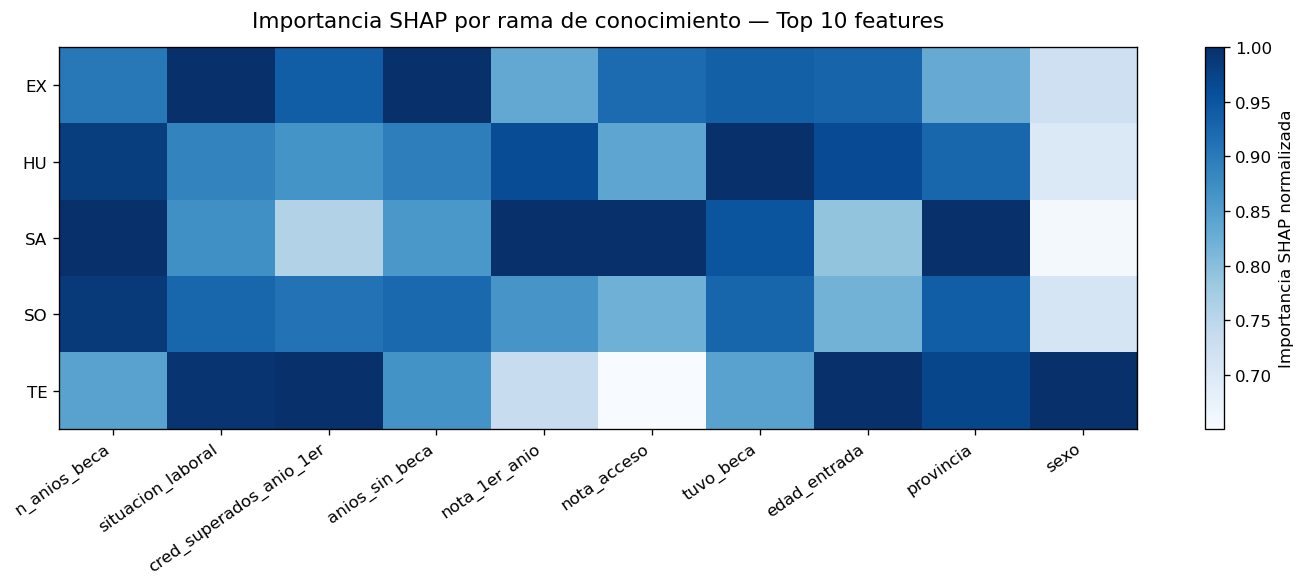

Heatmap rama guardado.


In [8]:
# 8. GRÁFICO 1 — HEATMAP SHAP POR RAMA
# Filas = ramas, columnas = top 10 features globales.
# Normalizado por columna para comparar entre features de escalas distintas.

top10_global = df_shap.abs().mean().nlargest(10).index.tolist()

fig, ax = plt.subplots(figsize=(12, 5))
data_heatmap = df_imp_rama[top10_global]
data_norm    = data_heatmap.div(data_heatmap.max())

im = ax.imshow(data_norm.values, aspect='auto', cmap='Blues')
ax.set_xticks(range(len(top10_global)))
ax.set_xticklabels(top10_global, rotation=35, ha='right', fontsize=10)
ax.set_yticks(range(len(data_norm)))
ax.set_yticklabels(data_norm.index, fontsize=10)
plt.colorbar(im, ax=ax, label='Importancia SHAP normalizada')
ax.set_title('Importancia SHAP por rama de conocimiento — Top 10 features', fontsize=13, pad=12)
plt.tight_layout()
ruta_heatmap_rama = DIR_RESULTS / 'shap_cohortes_rama_top10.png'
plt.savefig(ruta_heatmap_rama, dpi=120, bbox_inches='tight')
plt.show()
print('Heatmap rama guardado.')

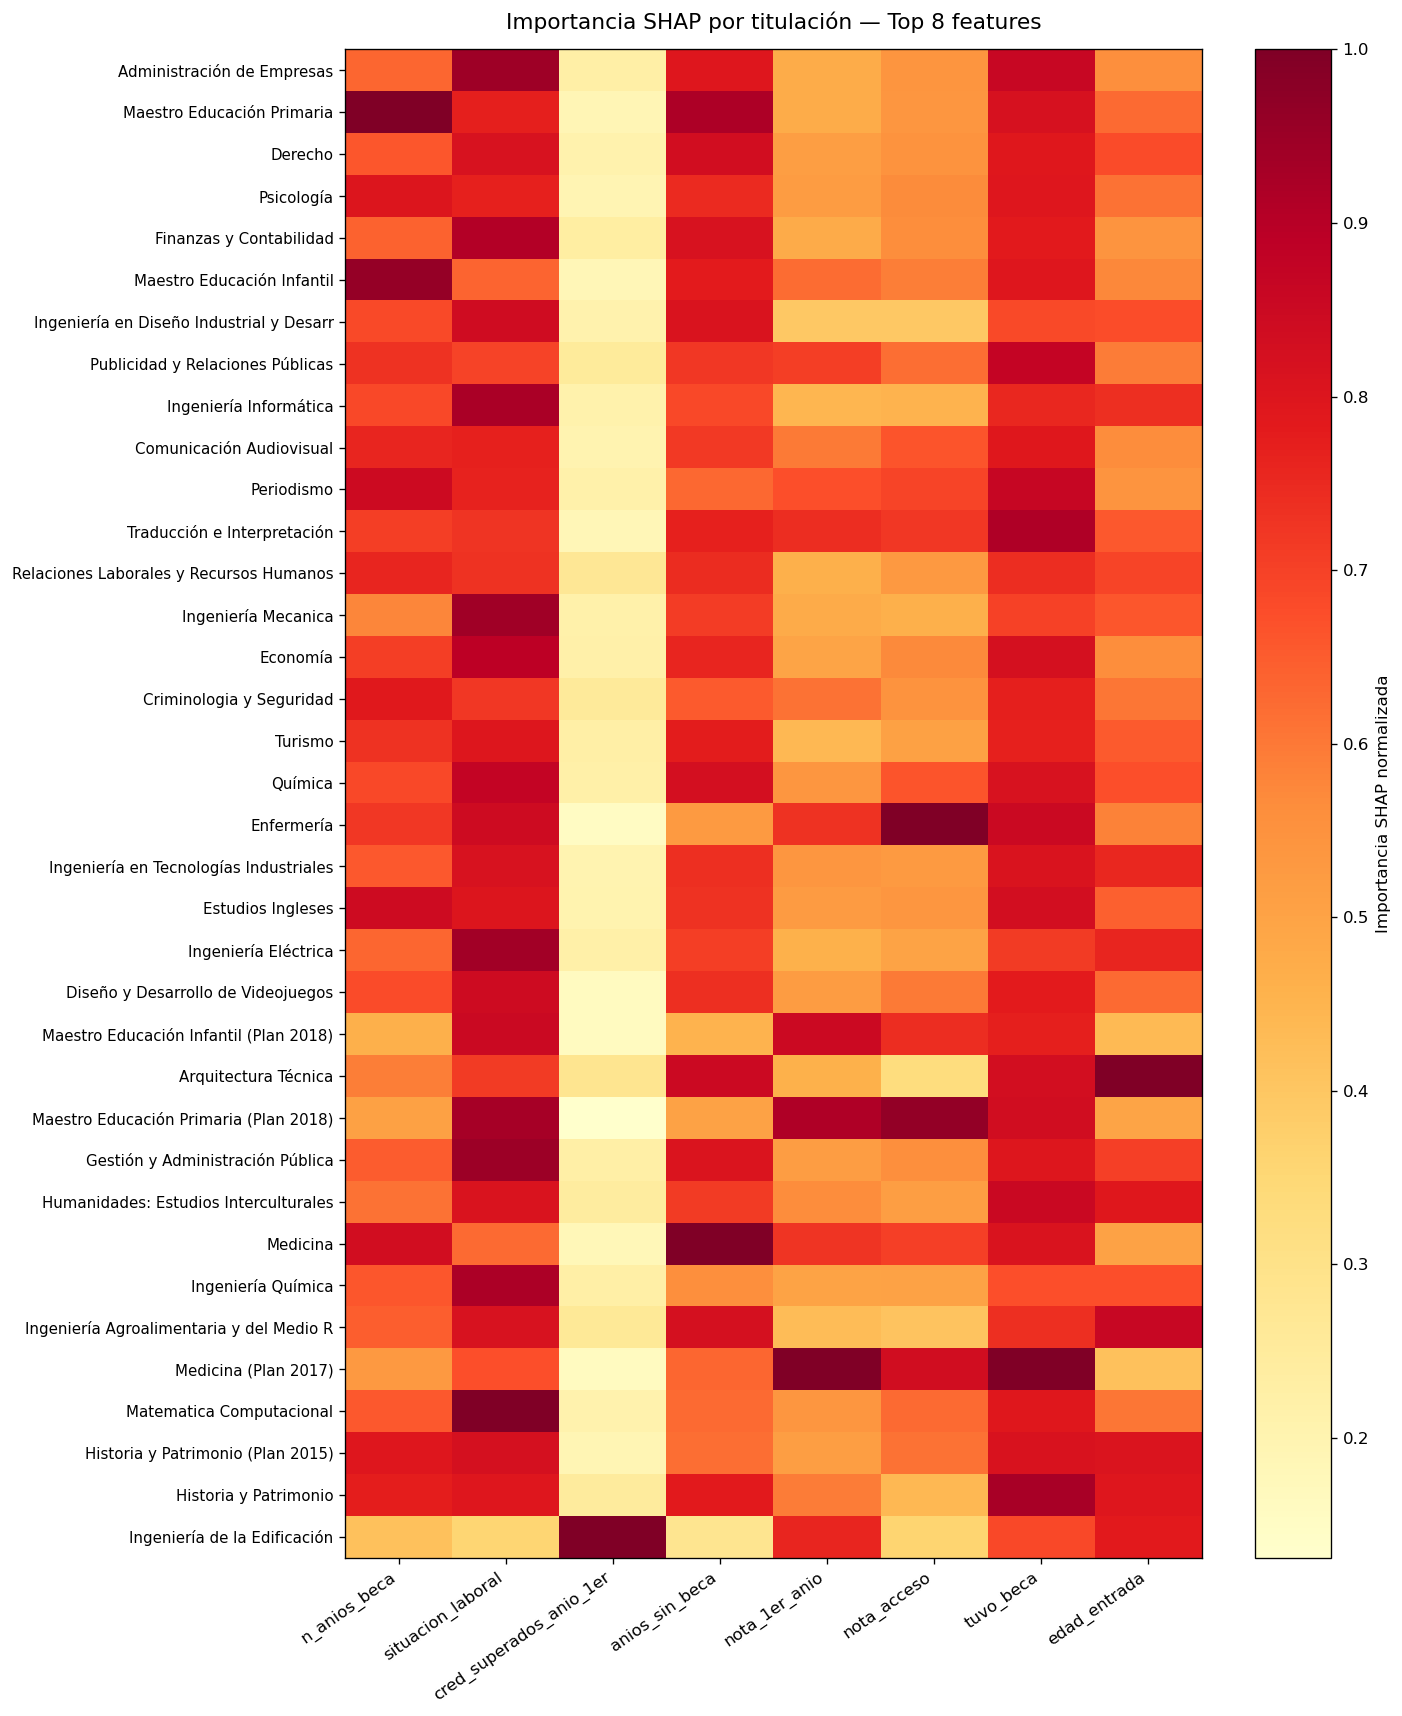

Heatmap titulación guardado.


In [9]:
# 9. GRÁFICO 2 — HEATMAP SHAP POR TITULACIÓN
# Filas = titulaciones (con >= 30 obs), columnas = top 8 features globales.
# Abreviamos nombres para que quepan en el eje Y.

top8_global = df_shap.abs().mean().nlargest(8).index.tolist()

nombres_cortos = [
    t.replace('Grado en Maestro en ', 'Maestro ').replace('Grado en ', '')[:40]
    for t in df_imp_tit.index
]

fig, ax = plt.subplots(figsize=(12, max(6, len(df_imp_tit) * 0.4)))
data_heatmap_tit = df_imp_tit[top8_global]
data_norm_tit    = data_heatmap_tit.div(data_heatmap_tit.max())

im2 = ax.imshow(data_norm_tit.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(top8_global)))
ax.set_xticklabels(top8_global, rotation=35, ha='right', fontsize=10)
ax.set_yticks(range(len(nombres_cortos)))
ax.set_yticklabels(nombres_cortos, fontsize=9)
plt.colorbar(im2, ax=ax, label='Importancia SHAP normalizada')
ax.set_title('Importancia SHAP por titulación — Top 8 features', fontsize=13, pad=12)
plt.tight_layout()
ruta_heatmap_tit = DIR_RESULTS / 'shap_cohortes_titulacion_top8.png'
plt.savefig(ruta_heatmap_tit, dpi=120, bbox_inches='tight')
plt.show()
print('Heatmap titulación guardado.')

In [10]:
# 10. ANÁLISIS — FEATURE DOMINANTE POR RAMA Y TITULACIÓN
# Qué variable lidera en cada cohorte — útil para el informe final y el tribunal.

print('Feature más importante por RAMA:')
for rama in df_imp_rama.index:
    top_feat = df_imp_rama.loc[rama].idxmax()
    top_val  = df_imp_rama.loc[rama].max()
    tasa     = df_meta[df_meta['rama'] == rama]['y_real'].mean()
    print(f'  {rama:35s} → {top_feat:30s} ({top_val:.4f}) | abandono={tasa:.2%}')

print('\nFeature más importante por TITULACIÓN (top 10 por tasa abandono):')
tasas_tit = (
    df_meta[df_meta['titulacion'].isin(titulaciones_validas)]
    .groupby('titulacion')['y_real'].mean()
    .nlargest(10)
)
for tit in tasas_tit.index:
    if tit in df_imp_tit.index:
        top_feat = df_imp_tit.loc[tit].idxmax()
        top_val  = df_imp_tit.loc[tit].max()
        tasa     = tasas_tit[tit]
        print(f'  {tit[:45]:45s} → {top_feat:25s} ({top_val:.4f}) | abandono={tasa:.2%}')

Feature más importante por RAMA:
  EX                                  → n_anios_beca                   (0.8734) | abandono=35.59%
  HU                                  → n_anios_beca                   (0.9509) | abandono=25.66%
  SA                                  → n_anios_beca                   (0.9680) | abandono=15.31%
  SO                                  → n_anios_beca                   (0.9540) | abandono=28.50%
  TE                                  → n_anios_beca                   (0.8168) | abandono=37.92%

Feature más importante por TITULACIÓN (top 10 por tasa abandono):
  Grado en Humanidades: Estudios Interculturale → n_anios_beca              (0.7795) | abandono=62.96%
  Grado en Ingeniería Eléctrica                 → situacion_laboral         (0.8135) | abandono=56.12%
  Grado en Historia y Patrimonio                → n_anios_beca              (0.9899) | abandono=52.94%
  Grado en Ingeniería Agroalimentaria y del Med → n_anios_beca              (0.8252) | abandono=52.86

In [11]:
# 11. GENERAR HTML
# render_pagina_desde_fichero — estándar del proyecto.

import base64

def img_b64(ruta: Path) -> str:
    if not ruta.exists():
        return ''
    with open(ruta, 'rb') as f:
        return base64.b64encode(f.read()).decode()

def bloque_imagen(b64: str, titulo: str, caption: str) -> str:
    if not b64:
        return f'<p style="color:#e53e3e">Imagen no disponible: {titulo}</p>'
    return (
        '<div style="margin:24px 0">'
        f'<h3 style="color:#2d3748; font-size:15px">{titulo}</h3>'
        f'<img src="data:image/png;base64,{b64}" style="max-width:100%; border-radius:6px; box-shadow:0 2px 8px rgba(0,0,0,.1)">'
        f'<p style="color:#718096; font-size:12px; margin-top:6px">{caption}</p>'
        '</div>'
    )

# Tabla resumen por rama
filas_rama = ''
for rama in df_imp_rama.index:
    top_feat = df_imp_rama.loc[rama].idxmax()
    top_val  = df_imp_rama.loc[rama].max()
    n_obs    = (df_meta['rama'] == rama).sum()
    tasa     = df_meta[df_meta['rama'] == rama]['y_real'].mean()
    filas_rama += (
        '<tr>'
        f'<td style="padding:7px 12px; font-weight:600">{rama}</td>'
        f'<td style="padding:7px 12px; text-align:center">{n_obs}</td>'
        f'<td style="padding:7px 12px; text-align:center">{tasa:.1%}</td>'
        f'<td style="padding:7px 12px">{top_feat}</td>'
        f'<td style="padding:7px 12px; text-align:right">{top_val:.4f}</td>'
        '</tr>'
    )

contenido = (
    '<h2 style="color:#2d3748">SHAP Cohortes — Importancia por Rama y Titulación</h2>'
    '<p style="color:#4a5568; font-size:14px; max-width:800px">'
    'Análisis de importancia SHAP segmentado por rama de conocimiento y titulación. '
    'Permite detectar si el modelo explica el abandono de forma homogénea en todos los grupos '
    'o si existen patrones diferenciados. Join realizado desde '
    '<code>df_exp_target_eda.parquet</code> (40 titulaciones, validado sin gaps).'
    '</p>'
    + bloque_imagen(
        img_b64(ruta_heatmap_rama),
        'Importancia SHAP por rama de conocimiento',
        'Cada fila es una rama. Cada columna es una de las 10 features más importantes globalmente. '
        'El color indica importancia normalizada: azul oscuro = muy importante en esa rama.')
    + bloque_imagen(
        img_b64(ruta_heatmap_tit),
        'Importancia SHAP por titulación',
        'Solo titulaciones con 30 o más observaciones en test. '
        'Permite identificar titulaciones donde el modelo usa features distintas para predecir abandono.')
    + '<h3 style="color:#2d3748; margin-top:28px">Resumen por rama — feature dominante</h3>'
    + '<table style="width:100%; border-collapse:collapse; font-size:13px">'
    + '<thead><tr style="background:#edf2f7">'
    + '<th style="padding:7px 12px; text-align:left">Rama</th>'
    + '<th style="padding:7px 12px; text-align:center">N test</th>'
    + '<th style="padding:7px 12px; text-align:center">Tasa abandono</th>'
    + '<th style="padding:7px 12px; text-align:left">Feature dominante</th>'
    + '<th style="padding:7px 12px; text-align:right">|SHAP| medio</th>'
    + '</tr></thead>'
    + f'<tbody>{filas_rama}</tbody></table>'
    + '<div style="margin-top:24px; padding:16px; background:#ebf8ff; '
    + 'border-left:4px solid #3182ce; border-radius:6px; font-size:13px; color:#2c5282">'
    + '<strong>Interpretación:</strong> Si la feature dominante varía mucho entre ramas, '
    + 'el modelo captura dinámicas distintas por área de conocimiento. '
    + 'Esto justifica intervenciones diferenciadas por titulación, no una política única.'
    + '</div>'
)

html_completo = render_pagina_desde_fichero('f6_m01c_shap_cohortes.ipynb', contenido)
ruta_html = ROOT / 'docs' / 'html' / 'fase6' / 'm01c_shap_cohortes.html'
ruta_html.parent.mkdir(parents=True, exist_ok=True)
ruta_html.write_text(html_completo, encoding='utf-8')
print(f'HTML generado: {ruta_html}')

HTML generado: C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI\docs\html\fase6\m01c_shap_cohortes.html
